Episode 0 | Epsilon: 0.995 
Episode 100 | Epsilon: 0.603 
Episode 200 | Epsilon: 0.365 
Episode 300 | Epsilon: 0.221 
Episode 400 | Epsilon: 0.134 


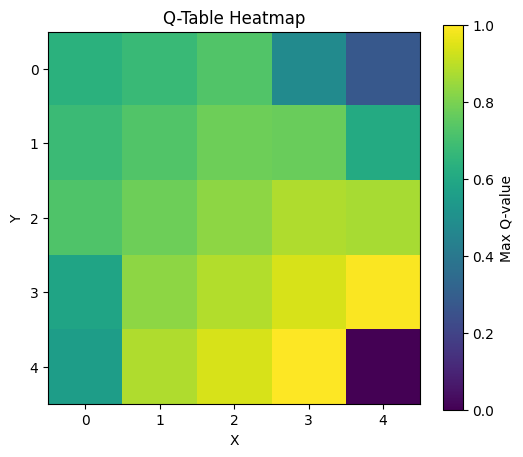

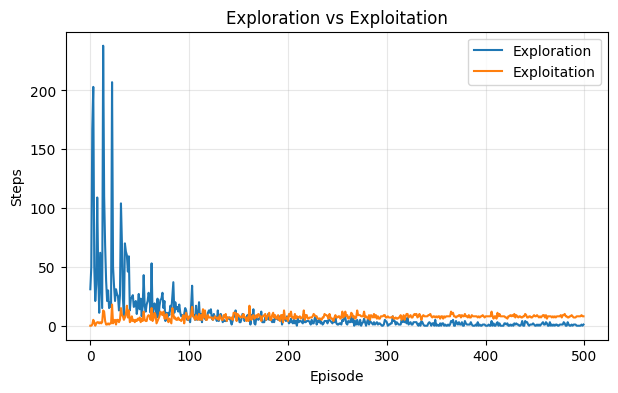

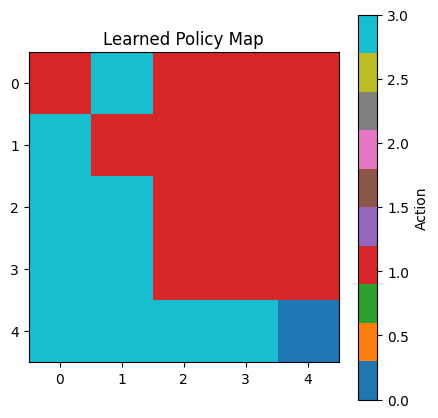

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. GridWorld Environment
GRID = 5
GOAL = (4, 4)
ACTIONS = 4 # up, down, left, right

def state_to_index(s):
    return s[0] * GRID + s[1]

def step(state, action):
    x, y = state
    if action == 0: x -= 1 # up
    elif action == 1: x += 1 # down
    elif action == 2: y -= 1 # left
    elif action == 3: y += 1 # right

    x = np.clip(x, 0, GRID-1)
    y = np.clip(y, 0, GRID-1)

    next_state = (x, y)
    reward = 1 if next_state == GOAL else -0.01
    done = next_state == GOAL

    return next_state, reward, done

# 2. Q-Learning Setup
states = GRID * GRID
Q = np.zeros((states, ACTIONS))

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05
episodes = 500

explore_steps = []
exploit_steps = []

# 3. Training
for ep in range(episodes):
    state = (0, 0)
    done = False
    explore = exploit = 0

    while not done:
        s = state_to_index(state)

        if np.random.rand() < epsilon:
            action = np.random.randint(ACTIONS)
            explore += 1
        else:
            action = np.argmax(Q[s])
            exploit += 1

        next_state, reward, done = step(state, action)
        ns = state_to_index(next_state)

        Q[s, action] += alpha * (
            reward + gamma * np.max(Q[ns]) - Q[s, action]
        )

        state = next_state

    explore_steps.append(explore)
    exploit_steps.append(exploit)

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    if ep % 100 == 0:
        print(f"Episode {ep} | Epsilon: {epsilon:.3f} ")
# Visualization

# 1. Q-table Heatmap
best_Q = np.max(Q, axis=1).reshape(GRID, GRID)

plt.figure(figsize=(6,5))
plt.imshow(best_Q, cmap="viridis")
plt.colorbar(label="Max Q-value")
plt.title("Q-Table Heatmap")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# 2. Exploration vs Exploitation
plt.figure(figsize=(7,4))
plt.plot(explore_steps, label="Exploration")
plt.plot(exploit_steps, label="Exploitation")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Exploration vs Exploitation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Learned Policy
policy = np.argmax(Q, axis=1).reshape(GRID, GRID)

plt.figure(figsize=(5,5))
plt.imshow(policy, cmap="tab10")
plt.colorbar(label="Action")
plt.title("Learned Policy Map")
plt.show()